In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from torch.nn.init import xavier_uniform_
from scipy import stats

print("✓ All libraries imported.")
print(f"  PyTorch version : {torch.__version__}")
print(f"  CUDA available  : {torch.cuda.is_available()}")

✓ All libraries imported.
  PyTorch version : 2.11.0+cu128
  CUDA available  : True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ── Load & prepare REAL dengue data (chronological split) ──────────
def load_and_prepare_data(test_frac=0.1, val_frac=0.1):
    data_loaded = pd.read_csv('/content/drive/MyDrive/dengue_thesis/dengue_srilanka_2017.csv')
    data_loaded = data_loaded.sort_values('time').reset_index(drop=True)

    t_all = data_loaded['time'].values.reshape(-1, 1)
    S_all = data_loaded['Susceptible'].values.reshape(-1, 1)
    I_all = data_loaded['Infected'].values.reshape(-1, 1)
    R_all = data_loaded['Recovered'].values.reshape(-1, 1)

    n       = len(data_loaded)
    n_test  = max(1, int(round(n * test_frac)))
    n_val   = max(1, int(round(n * val_frac)))
    n_train = n - n_test - n_val

    train_sl = slice(0, n_train)
    val_sl   = slice(n_train, n_train + n_val)
    test_sl  = slice(n_train + n_val, n)

    return (t_all[train_sl], t_all[val_sl], t_all[test_sl],
            S_all[train_sl], I_all[train_sl], R_all[train_sl],
            S_all[val_sl],   I_all[val_sl],   R_all[val_sl],
            S_all[test_sl],  I_all[test_sl],  R_all[test_sl])

(t_train_set, t_val_set, t_test_set,
 data_S_train_set, data_I_train_set, data_R_train_set,
 data_S_val_set,   data_I_val_set,   data_R_val_set,
 data_S_test_set,  data_I_test_set,  data_R_test_set) = load_and_prepare_data()

print(f"✓ Data loaded (real dengue, Sri Lanka 2017).")
print(f"  Train : {t_train_set.shape[0]} samples")
print(f"  Val   : {t_val_set.shape[0]} samples")
print(f"  Test  : {t_test_set.shape[0]} samples")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Data loaded (real dengue, Sri Lanka 2017).
  Train : 41 samples
  Val   : 5 samples
  Test  : 5 samples


In [3]:
# ── Device ───────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Device: {device}")

MU_BETA     = 0.145   # prior mean for beta
SIGMA_BETA  = 0.05    # prior std  for beta
MU_GAMMA    = 0.101   # prior mean for gamma
SIGMA_GAMMA = 0.03    # prior std  for gamma

# ── Loss weights ──────────────────────────────────────────────────
LAMBDA1 = 0.6   # data loss weight
LAMBDA2 = 0.3   # physics loss weight
LAMBDA3 = 0.1   # prior loss weight

# ── Training hyperparameters ──────────────────────────────────────
BATCH_SIZE  = 32
EPOCHS_MR   = 3000
# PATIENCE_MR = 700

# ── Multi-run config ──────────────────────────────────────────────
N_RUNS = 20
SEEDS  = [42, 123, 7, 2024, 999, 17, 55, 88, 314, 271,
          101, 202, 303, 404, 505, 606, 707, 808, 909, 1001]

print(f"\n  Prior  : mu_beta={MU_BETA}, sigma_beta={SIGMA_BETA}  |  "
      f"mu_gamma={MU_GAMMA}, sigma_gamma={SIGMA_GAMMA}")
print(f"  Implied prior R0 = mu_beta/mu_gamma = {MU_BETA/MU_GAMMA:.2f}")
print(f"  N_RUNS = {N_RUNS}  |  Seeds  = {SEEDS}")

  Device: cuda

  Prior  : mu_beta=0.145, sigma_beta=0.05  |  mu_gamma=0.101, sigma_gamma=0.03
  Implied prior R0 = mu_beta/mu_gamma = 1.44
  N_RUNS = 20  |  Seeds  = [42, 123, 7, 2024, 999, 17, 55, 88, 314, 271, 101, 202, 303, 404, 505, 606, 707, 808, 909, 1001]


In [4]:
class SIRPINN(nn.Module):

    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim,      hidden_dims[0]), nn.Tanh(),
            nn.Linear(hidden_dims[0], hidden_dims[1]), nn.Tanh(),
            nn.Linear(hidden_dims[1], hidden_dims[2]), nn.Tanh(),
            nn.Linear(hidden_dims[2], output_dim)
        )

        # Xavier initialisation
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0)

        # Learnable SIR parameters
        self.params = nn.ParameterDict({
            'beta' : nn.Parameter(torch.tensor(1.0, dtype=torch.float32)),
            'gamma': nn.Parameter(torch.tensor(1.0, dtype=torch.float32))
        })

    def forward(self, t):
        return self.network(t)

print("✓ SIRPINN class defined.")
print("  Architecture : 1 -> 50 -> 50 -> 50 -> 3  (Tanh activations)")
print("  Learnable    : beta (init=1.0), gamma (init=1.0)")

✓ SIRPINN class defined.
  Architecture : 1 -> 50 -> 50 -> 50 -> 3  (Tanh activations)
  Learnable    : beta (init=1.0), gamma (init=1.0)


In [5]:
def to_tensor(x, device, requires_grad=False):
    """Convert numpy array to float32 tensor on device."""
    return torch.tensor(x, dtype=torch.float32,
                        requires_grad=requires_grad).to(device)

def prepare_dataloader(t, S, I, R, batch_size, device):
    """Build a shuffled DataLoader from numpy arrays."""
    t_t = to_tensor(t, device, requires_grad=True)
    S_t = to_tensor(S, device)
    I_t = to_tensor(I, device)
    R_t = to_tensor(R, device)
    ds  = TensorDataset(t_t, S_t, I_t, R_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=True)

# ── Prepare shared train/val/test tensors (used across all runs) ──
t_train_tensor      = to_tensor(t_train_set,      device, requires_grad=True)
data_S_train_tensor = to_tensor(data_S_train_set, device)
data_I_train_tensor = to_tensor(data_I_train_set, device)
data_R_train_tensor = to_tensor(data_R_train_set, device)

t_val_tensor        = to_tensor(t_val_set,        device)
data_S_val_tensor   = to_tensor(data_S_val_set,   device)
data_I_val_tensor   = to_tensor(data_I_val_set,   device)
data_R_val_tensor   = to_tensor(data_R_val_set,   device)

t_test_tensor       = to_tensor(t_test_set,       device)
data_S_test_tensor  = to_tensor(data_S_test_set,  device)
data_I_test_tensor  = to_tensor(data_I_test_set,  device)
data_R_test_tensor  = to_tensor(data_R_test_set,  device)

print("✓ Helper functions defined.")
print("  Shared train/val/test tensors ready.")

✓ Helper functions defined.
  Shared train/val/test tensors ready.


In [6]:
def train_with_physics_loss_sir_v2(
        model, optimizer, train_loader_local,
        epochs,
        t_train_tensor, data_S_train_tensor, data_I_train_tensor, data_R_train_tensor,
        t_val_tensor,   data_S_val_tensor,   data_I_val_tensor,   data_R_val_tensor,
        mu_beta_prior,  sigma_beta_prior,
        mu_gamma_prior, sigma_gamma_prior,
        lambda1=0.6, lambda2=0.3, lambda3=0.1,
        verbose=False):

    train_losses        = []
    val_losses          = []
    parameter_estimates = {key: [] for key in model.params.keys()}
    best_val_loss       = float('inf')
    no_improve          = 0
    best_weights        = None  # Bug fix: track best model state (lowest val loss)

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for t_batch, S_batch, I_batch, R_batch in train_loader_local:
            optimizer.zero_grad()
            t_batch = t_batch.requires_grad_(True)

            out    = model(t_batch)
            S_pred = out[:, 0:1]
            I_pred = out[:, 1:2]
            R_pred = out[:, 2:3]

            beta  = model.params['beta']
            gamma = model.params['gamma']

            # Autograd derivatives
            dS_dt = torch.autograd.grad(S_pred, t_batch,
                        grad_outputs=torch.ones_like(S_pred), create_graph=True)[0]
            dI_dt = torch.autograd.grad(I_pred, t_batch,
                        grad_outputs=torch.ones_like(I_pred), create_graph=True)[0]
            dR_dt = torch.autograd.grad(R_pred, t_batch,
                        grad_outputs=torch.ones_like(R_pred), create_graph=True)[0]

            # Physics loss (SIR ODE residuals)
            physics_loss = (torch.mean((dS_dt + beta * S_pred * I_pred)**2) +
                            torch.mean((dI_dt - beta * S_pred * I_pred + gamma * I_pred)**2) +
                            torch.mean((dR_dt - gamma * I_pred)**2))

            # Data loss (MSE)
            data_loss = (torch.mean((S_pred - S_batch)**2) +
                         torch.mean((I_pred - I_batch)**2) +
                         torch.mean((R_pred - R_batch)**2))

            # Gaussian prior loss — MAP estimation (our contribution)
            prior_loss = ((beta  - mu_beta_prior )**2 / (2 * sigma_beta_prior**2)  +
                          (gamma - mu_gamma_prior)**2 / (2 * sigma_gamma_prior**2))

            loss = lambda2 * physics_loss + lambda1 * data_loss + lambda3 * prior_loss
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        epoch_loss = sum(batch_losses) / len(batch_losses)
        train_losses.append(epoch_loss)

        for key in parameter_estimates:
            parameter_estimates[key].append(model.params[key].item())

        # Validation
        model.eval()
        with torch.no_grad():
            out_val  = model(t_val_tensor)
            val_loss = (torch.mean((out_val[:,0:1] - data_S_val_tensor)**2) +
                        torch.mean((out_val[:,1:2] - data_I_val_tensor)**2) +
                        torch.mean((out_val[:,2:3] - data_R_val_tensor)**2))
            val_losses.append(val_loss.item())


        if val_loss.item() < (best_val_loss - 1e-5):
            best_val_loss = val_loss.item()
            no_improve    = 0
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        # if no_improve >= patience:
        #     if verbose:
        #         print(f'  Early stopping at epoch {epoch}')
        #     break

        if verbose and epoch % 500 == 0:
            print(f'  Epoch {epoch:5d} | beta={beta.item():.5f} | '
                  f'gamma={gamma.item():.6f} | val={val_loss.item():.6f}')


    if best_weights is not None:
        model.load_state_dict(best_weights)
        for key in parameter_estimates:
            parameter_estimates[key].append(model.params[key].item())

    return train_losses, val_losses, parameter_estimates


def test_rmse(model, t_test_tensor, S_test_t, I_test_t, R_test_t):

    model.eval()
    with torch.no_grad():
        out = model(t_test_tensor)
        rmse = torch.sqrt(torch.mean((out[:,0:1] - S_test_t)**2) +
                           torch.mean((out[:,1:2] - I_test_t)**2) +
                           torch.mean((out[:,2:3] - R_test_t)**2))
    return rmse.item()

print("✓ train_with_physics_loss_sir_v2() and test_rmse() defined.")
print("  (bug fix applied: best validation-loss weights are now saved and restored)")

✓ train_with_physics_loss_sir_v2() and test_rmse() defined.
  (bug fix applied: best validation-loss weights are now saved and restored)


In [7]:
def get_fresh_model_optimizer(seed: int):
    """Fresh SIRPINN + Adam, fully seeded for reproducibility."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    m   = SIRPINN(input_dim=1, hidden_dims=[50, 50, 50], output_dim=3).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    return m, opt

def get_fresh_loader(seed: int):
    """DataLoader with seed-controlled shuffling."""
    torch.manual_seed(seed)
    return prepare_dataloader(
        t_train_set, data_S_train_set, data_I_train_set, data_R_train_set,
        BATCH_SIZE, device)

print("✓ Multi-run helper functions defined.")
print(f"  Ready to run {N_RUNS} independent experiments.")

✓ Multi-run helper functions defined.
  Ready to run 20 independent experiments.


In [8]:
# ══════════════════════════════════════════════════════════════════
# MAIN EXPERIMENT — 20 Independent Runs — Real Dengue Data
# Each run: fresh model weights + fresh DataLoader shuffle
# Same hyperparameters, same real data, different random seed
# ══════════════════════════════════════════════════════════════════

beta_finals  = []
gamma_finals = []
beta_traces  = []
gamma_traces = []
rmse_finals  = []
epochs_ran   = []

print("=" * 65)
print(f"  Starting {N_RUNS} independent runs (real dengue data)")
print("=" * 65)

for run_idx, seed in enumerate(SEEDS):
    print(f"\n[Run {run_idx + 1:02d}/{N_RUNS}]  seed = {seed}")

    m_r, opt_r = get_fresh_model_optimizer(seed)
    loader_r   = get_fresh_loader(seed)

    _, _, p_est = train_with_physics_loss_sir_v2(
        model               = m_r,
        optimizer           = opt_r,
        train_loader_local  = loader_r,
        epochs              = EPOCHS_MR,
        t_train_tensor      = t_train_tensor,
        data_S_train_tensor = data_S_train_tensor,
        data_I_train_tensor = data_I_train_tensor,
        data_R_train_tensor = data_R_train_tensor,
        t_val_tensor        = t_val_tensor,
        data_S_val_tensor   = data_S_val_tensor,
        data_I_val_tensor   = data_I_val_tensor,
        data_R_val_tensor   = data_R_val_tensor,
        mu_beta_prior       = MU_BETA,
        sigma_beta_prior    = SIGMA_BETA,
        mu_gamma_prior      = MU_GAMMA,
        sigma_gamma_prior   = SIGMA_GAMMA,
        lambda1=LAMBDA1, lambda2=LAMBDA2, lambda3=LAMBDA3,
        verbose=True
    )

    fb = p_est['beta'][-1]
    fg = p_est['gamma'][-1]
    beta_finals.append(fb)
    gamma_finals.append(fg)
    beta_traces.append(p_est['beta'])
    gamma_traces.append(p_est['gamma'])
    epochs_ran.append(len(p_est['beta']))
    rmse_finals.append(test_rmse(m_r, t_test_tensor,
                                  data_S_test_tensor, data_I_test_tensor, data_R_test_tensor))

    print(f"  → beta_hat = {fb:.5f}  |  gamma_hat = {fg:.6f}  |  "
          f"test RMSE = {rmse_finals[-1]:.6f}  |  epochs = {epochs_ran[-1]}")

print("\n✓ All runs complete.")

  Starting 20 independent runs (real dengue data)

[Run 01/20]  seed = 42
  Epoch     0 | beta=0.99800 | gamma=0.998000 | val=3.586903
  Epoch   500 | beta=0.30513 | gamma=0.288840 | val=0.000121
  Epoch  1000 | beta=0.15090 | gamma=0.110083 | val=0.000184
  Epoch  1500 | beta=0.14501 | gamma=0.101036 | val=0.000077
  Epoch  2000 | beta=0.14500 | gamma=0.101000 | val=0.000144
  Epoch  2500 | beta=0.14500 | gamma=0.101000 | val=0.000405
  → beta_hat = 0.14500  |  gamma_hat = 0.101000  |  test RMSE = 0.005178  |  epochs = 3001

[Run 02/20]  seed = 123
  Epoch     0 | beta=0.99800 | gamma=0.998000 | val=0.356379
  Epoch   500 | beta=0.30510 | gamma=0.288835 | val=0.000105
  Epoch  1000 | beta=0.15090 | gamma=0.110082 | val=0.000190
  Epoch  1500 | beta=0.14501 | gamma=0.101036 | val=0.000214
  Epoch  2000 | beta=0.14500 | gamma=0.101000 | val=0.000285
  Epoch  2500 | beta=0.14500 | gamma=0.101000 | val=0.000119
  → beta_hat = 0.29143  |  gamma_hat = 0.273978  |  test RMSE = 0.009014  |  e

In [9]:
# ── Compute all statistics (no ground truth — real data) ─────────
beta_arr  = np.array(beta_finals)
gamma_arr = np.array(gamma_finals)
rmse_arr  = np.array(rmse_finals)
r0_arr    = beta_arr / gamma_arr

beta_mean    = np.mean(beta_arr)
beta_std     = np.std(beta_arr,  ddof=1)
beta_se      = stats.sem(beta_arr)
beta_ci95    = stats.t.interval(0.95, df=N_RUNS-1, loc=beta_mean,  scale=beta_se)

gamma_mean   = np.mean(gamma_arr)
gamma_std    = np.std(gamma_arr, ddof=1)
gamma_se     = stats.sem(gamma_arr)
gamma_ci95   = stats.t.interval(0.95, df=N_RUNS-1, loc=gamma_mean, scale=gamma_se)

r0_mean      = np.mean(r0_arr)
r0_std       = np.std(r0_arr, ddof=1)

rmse_mean    = np.mean(rmse_arr)
rmse_std     = np.std(rmse_arr, ddof=1)

# Coefficient of variation — still valid without ground truth
beta_rel_std   = beta_std  / beta_mean  * 100
gamma_rel_std  = gamma_std / gamma_mean * 100

# Distance from literature prior (NOT error vs. true value)
beta_prior_dev_pct  = abs(beta_mean  - MU_BETA)  / MU_BETA  * 100
gamma_prior_dev_pct = abs(gamma_mean - MU_GAMMA) / MU_GAMMA * 100

print("✓ Statistics computed.")

✓ Statistics computed.


In [10]:
print("=" * 65)
print(f"  RESULTS  (N = {N_RUNS} independent runs, real dengue data)")
print("=" * 65)

print(f"\n  beta  (transmission rate)")
print(f"     Literature prior mu_beta : {MU_BETA:.4f}")
print(f"     Mean +/- SD              : {beta_mean:.4f} +/- {beta_std:.4f}")
print(f"     95% CI                   : ({beta_ci95[0]:.4f}, {beta_ci95[1]:.4f})")
print(f"     Deviation from prior (%) : {beta_prior_dev_pct:.2f}%")
print(f"     CV (%)                   : {beta_rel_std:.2f}%")

print(f"\n  gamma  (recovery rate)")
print(f"     Literature prior mu_gamma: {MU_GAMMA:.5f}")
print(f"     Mean +/- SD              : {gamma_mean:.5f} +/- {gamma_std:.5f}")
print(f"     95% CI                   : ({gamma_ci95[0]:.5f}, {gamma_ci95[1]:.5f})")
print(f"     Deviation from prior (%) : {gamma_prior_dev_pct:.2f}%")
print(f"     CV (%)                   : {gamma_rel_std:.2f}%")

print(f"\n  R0 = beta/gamma            : {r0_mean:.3f} +/- {r0_std:.3f}")
print(f"  Held-out test RMSE         : {rmse_mean:.6f} +/- {rmse_std:.6f}")

print(f"\n  Training epochs   : {np.mean(epochs_ran):.0f} +/- {np.std(epochs_ran):.0f}  "
      f"(range: {min(epochs_ran)}-{max(epochs_ran)})")
print("=" * 65)
print(f"\n  Paper-ready:")
print(f"    beta_hat  = {beta_mean:.4f} +/- {beta_std:.4f}   (prior: {MU_BETA})")
print(f"    gamma_hat = {gamma_mean:.5f} +/- {gamma_std:.5f}  (prior: {MU_GAMMA})")
print(f"    R0_hat    = {r0_mean:.3f} +/- {r0_std:.3f}")
print(f"    Test RMSE = {rmse_mean:.6f} +/- {rmse_std:.6f}")
print("=" * 65)

  RESULTS  (N = 20 independent runs, real dengue data)

  beta  (transmission rate)
     Literature prior mu_beta : 0.1450
     Mean +/- SD              : 0.2749 +/- 0.2248
     95% CI                   : (0.1697, 0.3801)
     Deviation from prior (%) : 89.59%
     CV (%)                   : 81.77%

  gamma  (recovery rate)
     Literature prior mu_gamma: 0.10100
     Mean +/- SD              : 0.24287 +/- 0.24202
     95% CI                   : (0.12960, 0.35614)
     Deviation from prior (%) : 140.47%
     CV (%)                   : 99.65%

  R0 = beta/gamma            : 1.300 +/- 0.194
  Held-out test RMSE         : 0.004941 +/- 0.001637

  Training epochs   : 3001 +/- 0  (range: 3001-3001)

  Paper-ready:
    beta_hat  = 0.2749 +/- 0.2248   (prior: 0.145)
    gamma_hat = 0.24287 +/- 0.24202  (prior: 0.101)
    R0_hat    = 1.300 +/- 0.194
    Test RMSE = 0.004941 +/- 0.001637


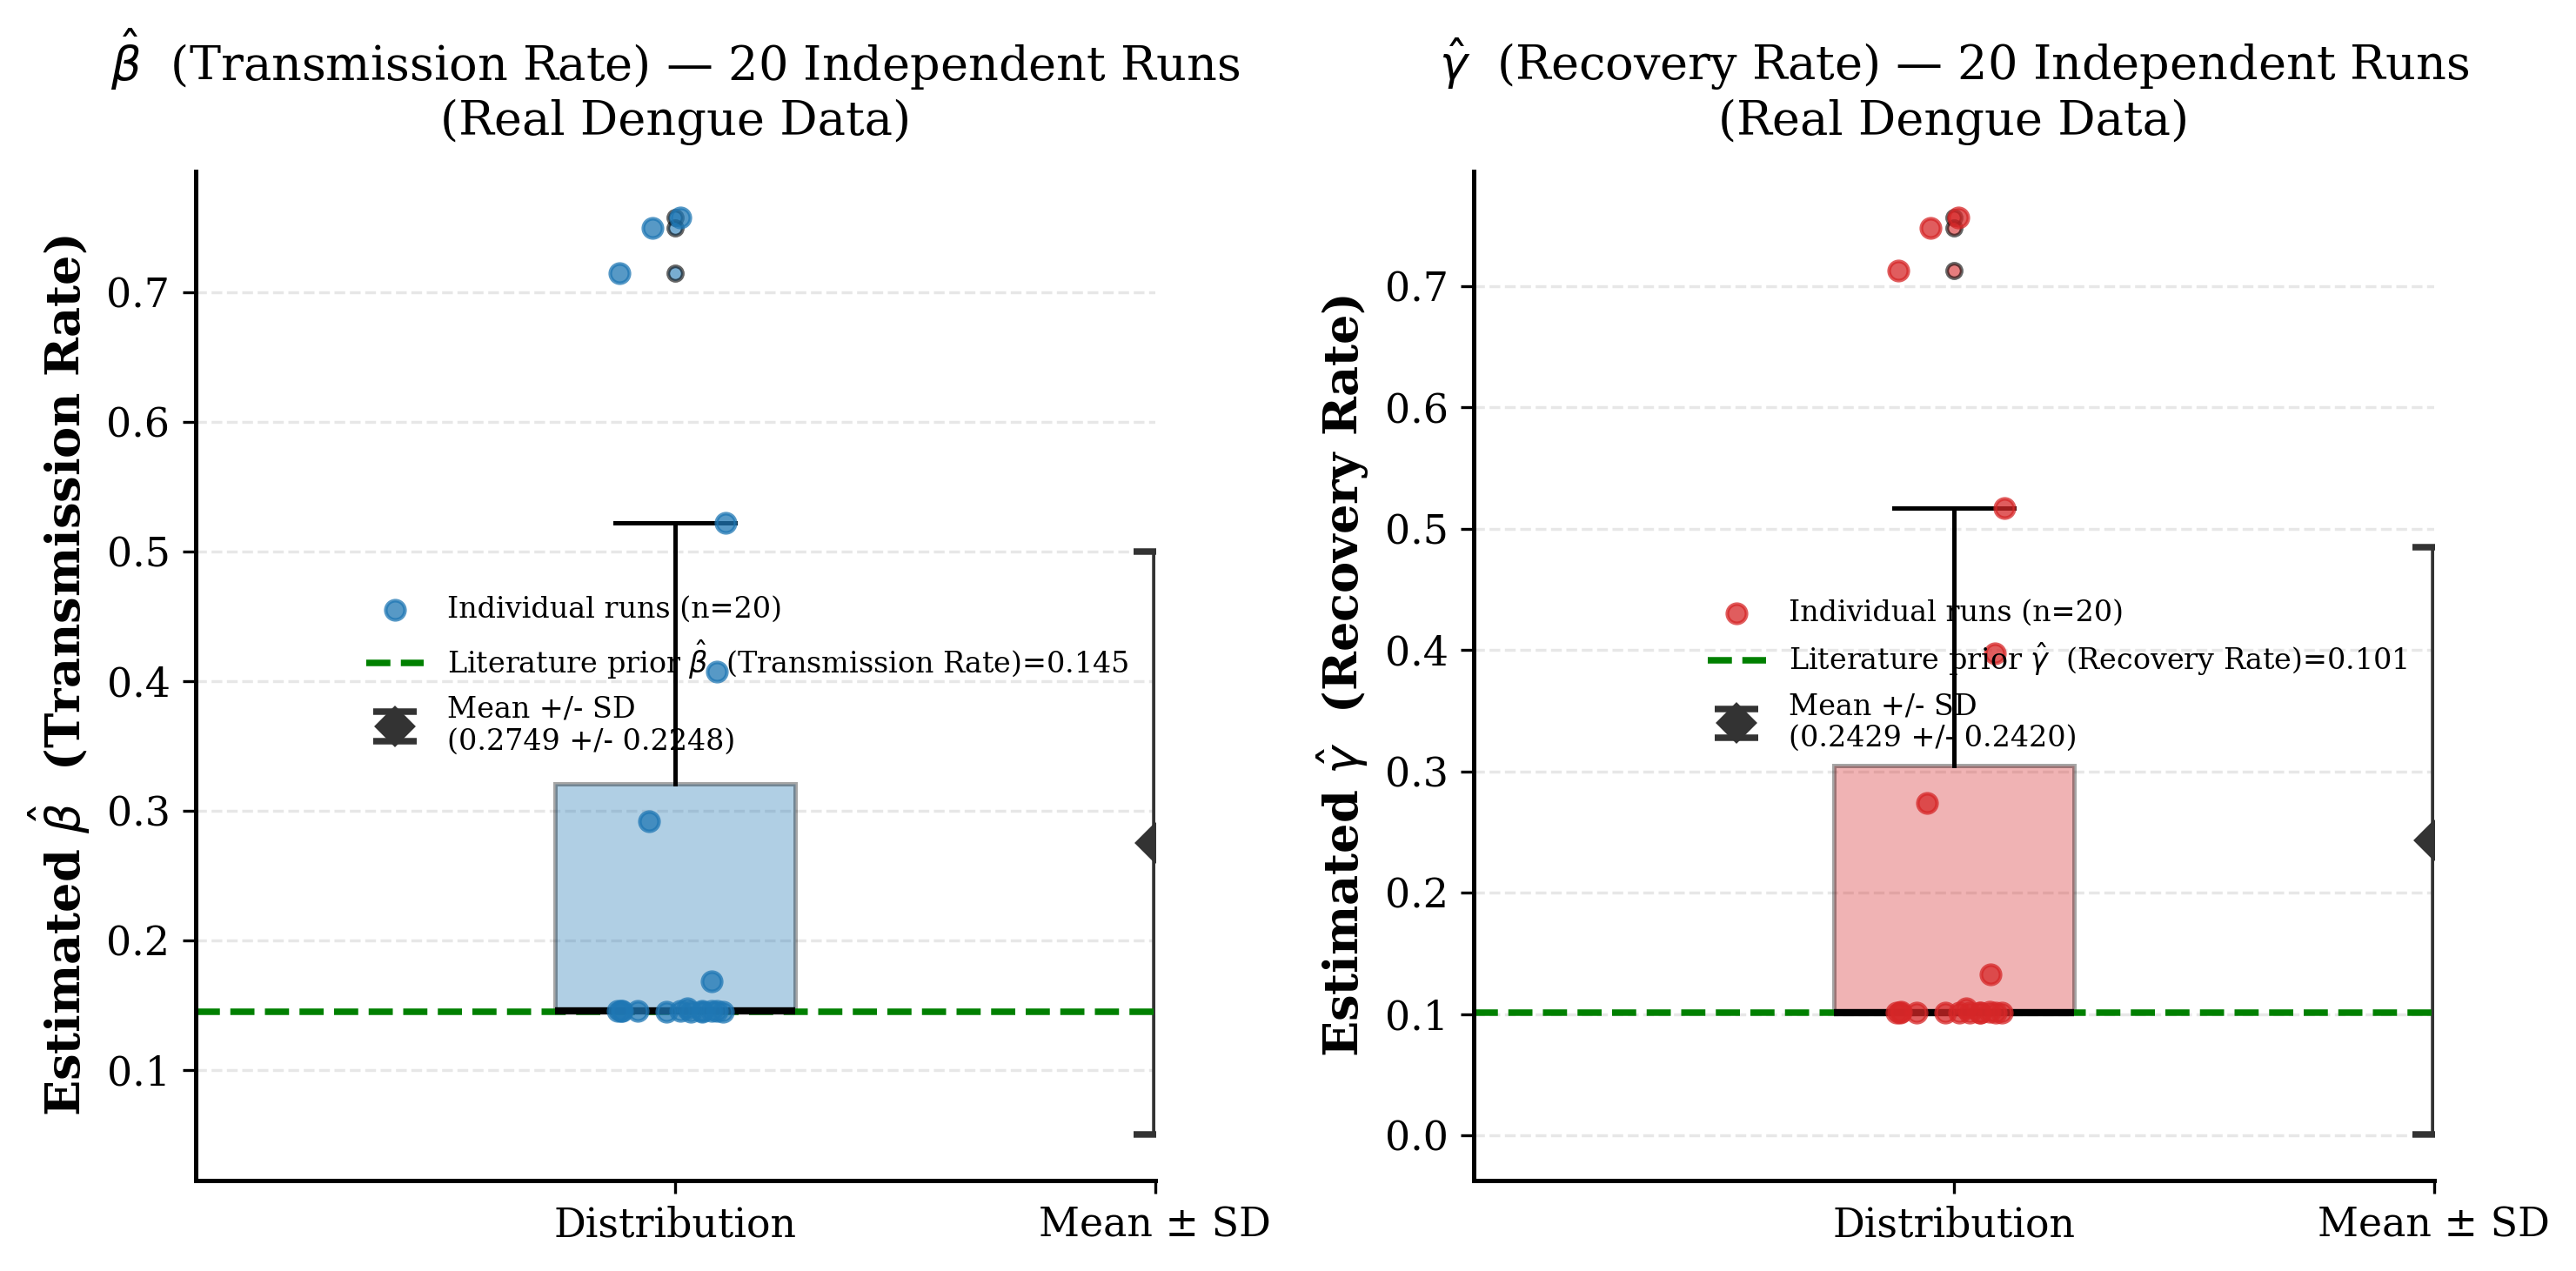

Saved: Fig_MultiRun_BoxStrip_RealData.png


In [11]:
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 13, 'axes.titlesize': 13,
    'legend.fontsize': 10, 'axes.linewidth': 1.2,
})

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

for ax, arr, prior_val, label, color, unit in zip(
        axes,
        [beta_arr,  gamma_arr],
        [MU_BETA,   MU_GAMMA],
        [r'$\hat{\beta}$  (Transmission Rate)',
         r'$\hat{\gamma}$  (Recovery Rate)'],
        ['#1f77b4', '#d62728'],
        [r'$\beta$', r'$\gamma$']):

    mn = np.mean(arr)
    sd = np.std(arr, ddof=1)

    # Box plot
    ax.boxplot(arr, positions=[0.6], widths=0.25,
               patch_artist=True,
               boxprops    =dict(facecolor=color, alpha=0.35, linewidth=1.2),
               medianprops =dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=1.2),
               capprops    =dict(linewidth=1.2),
               flierprops  =dict(marker='o', markersize=4,
                                 markerfacecolor=color, alpha=0.6))

    # Strip (individual points)
    jitter = np.random.default_rng(0).uniform(-0.06, 0.06, size=len(arr))
    ax.scatter(0.6 + jitter, arr, color=color, alpha=0.75,
               s=28, zorder=5, label=f'Individual runs (n={N_RUNS})')

    # Mean +/- SD error bar
    ax.errorbar(1.1, mn, yerr=sd, fmt='D', color='#333333',
                markersize=7, capsize=6, capthick=1.8, linewidth=1.8,
                label=f'Mean +/- SD\n({mn:.4f} +/- {sd:.4f})')

    # Literature prior line (NOT ground truth)
    ax.axhline(prior_val, color='green', linestyle='--',
               linewidth=1.8, label=f'Literature prior {label}={prior_val}')

    ax.set_xticks([0.6, 1.1])
    ax.set_xticklabels(['Distribution', 'Mean ± SD'])
    ax.set_ylabel(f'Estimated {label}', fontweight='bold')
    ax.set_title(f'{label} — {N_RUNS} Independent Runs\n(Real Dengue Data)', pad=10)
    ax.legend(frameon=False, fontsize=8, loc='best')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('Fig_MultiRun_BoxStrip_RealData.png', dpi=500, bbox_inches='tight')
plt.show()
print("Saved: Fig_MultiRun_BoxStrip_RealData.png")

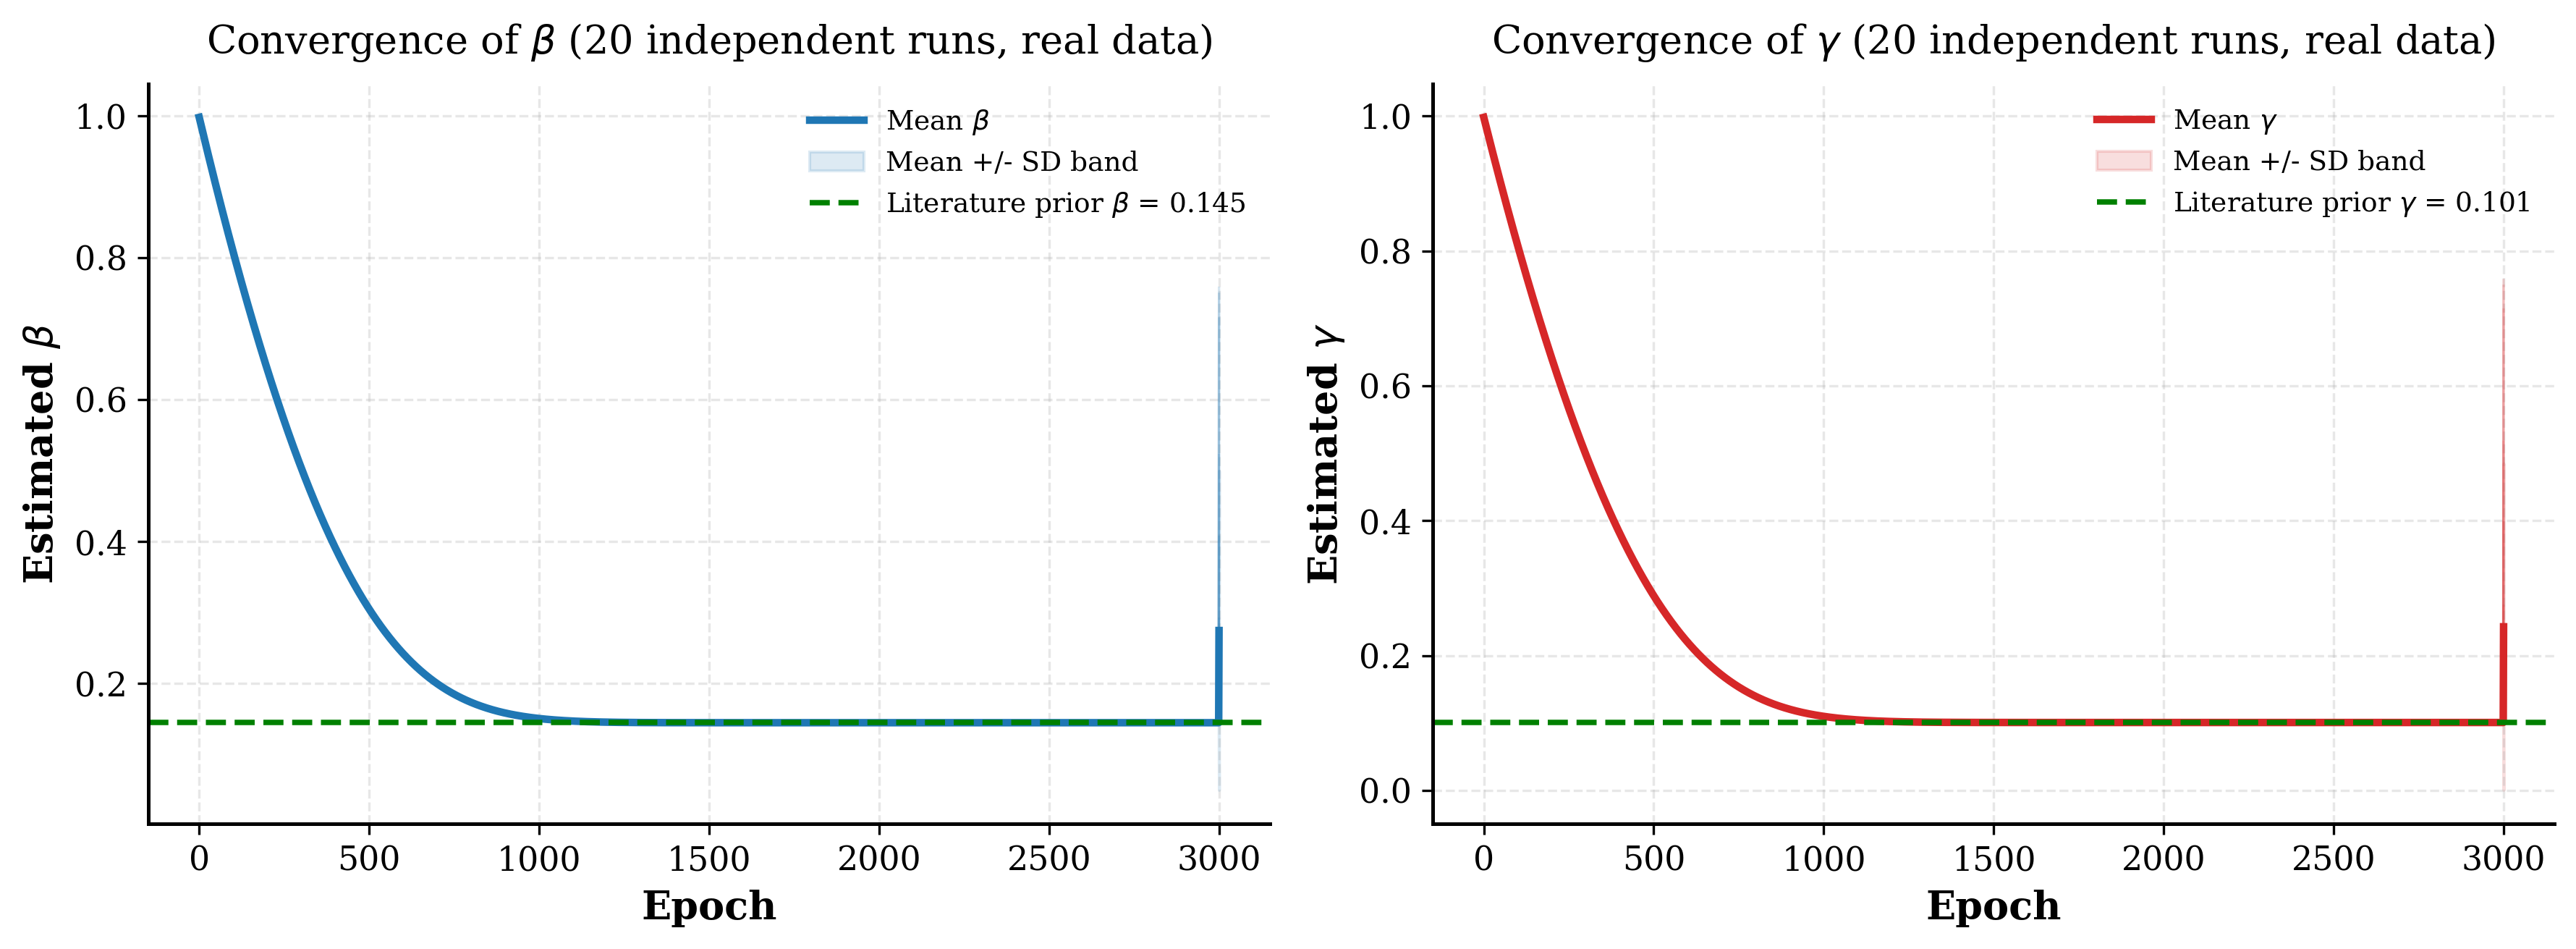

Saved: Fig_MultiRun_Convergence_RealData.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=300)

for ax, traces, prior_val, param_label, color in zip(
        axes,
        [beta_traces,  gamma_traces],
        [MU_BETA,      MU_GAMMA],
        [r'$\beta$',   r'$\gamma$'],
        ['#1f77b4',    '#d62728']):

    min_len = min(len(t) for t in traces)
    mat     = np.array([t[:min_len] for t in traces])
    ep      = np.arange(min_len)

    # Individual traces (faint spaghetti)
    for trace in traces:
        ax.plot(np.arange(len(trace)), trace,
                color=color, alpha=0.18, linewidth=0.8)

    # Mean trace (bold)
    ax.plot(ep, mat.mean(axis=0),
            color=color, linewidth=2.5, label=f'Mean {param_label}')

    # +/-SD band
    ax.fill_between(ep,
                    mat.mean(axis=0) - mat.std(axis=0, ddof=1),
                    mat.mean(axis=0) + mat.std(axis=0, ddof=1),
                    color=color, alpha=0.15, label='Mean +/- SD band')

    # Literature prior line (NOT ground truth)
    ax.axhline(prior_val, color='green', linestyle='--',
               linewidth=1.8, label=f'Literature prior {param_label} = {prior_val}')

    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel(f'Estimated {param_label}', fontweight='bold')
    ax.set_title(f'Convergence of {param_label} ({N_RUNS} independent runs, real data)', pad=10)
    ax.legend(frameon=False, fontsize=9, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('Fig_MultiRun_Convergence_RealData.png', dpi=500, bbox_inches='tight')
plt.show()
print("Saved: Fig_MultiRun_Convergence_RealData.png")

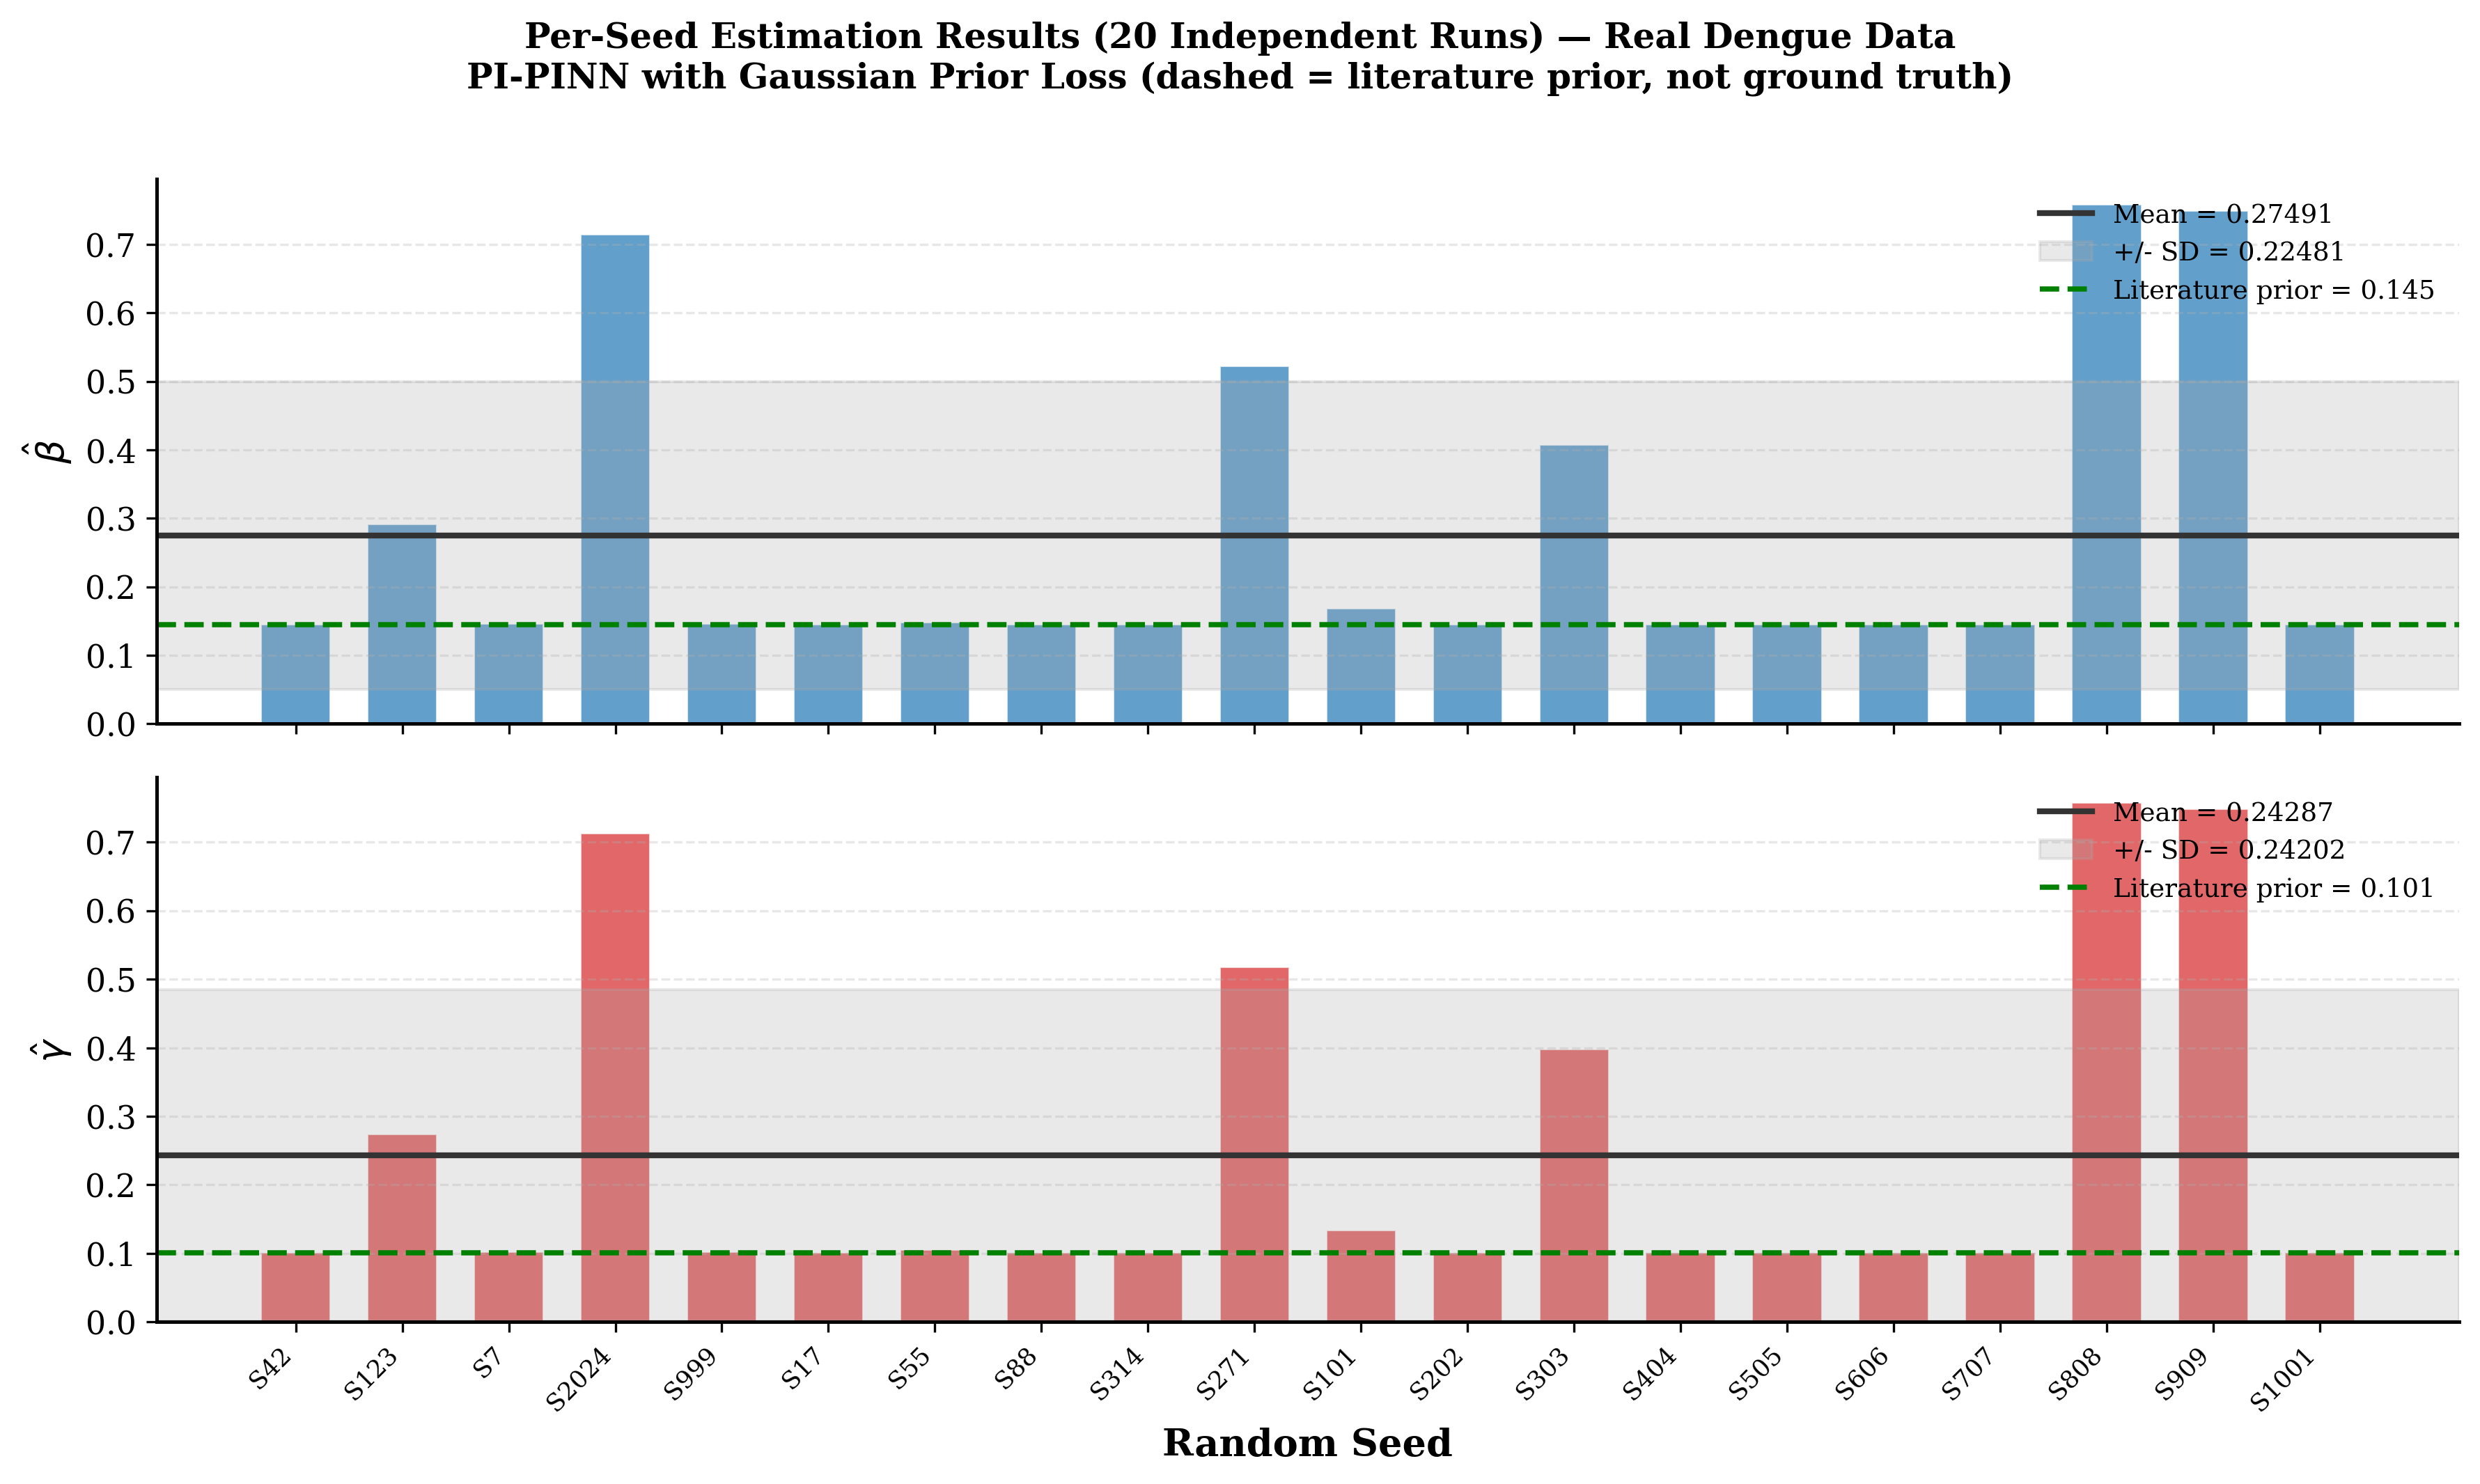

Saved: Fig_MultiRun_PerSeed_RealData.png


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), dpi=300, sharex=True)

x      = np.arange(N_RUNS)
labels = [f'S{s}' for s in SEEDS]

for ax, arr, prior_val, mn, sd, param_label, color in zip(
        axes,
        [beta_arr,   gamma_arr],
        [MU_BETA,    MU_GAMMA],
        [beta_mean,  gamma_mean],
        [beta_std,   gamma_std],
        [r'$\hat{\beta}$', r'$\hat{\gamma}$'],
        ['#1f77b4',  '#d62728']):

    ax.bar(x, arr, color=color, alpha=0.70, width=0.65,
           edgecolor='white', linewidth=0.5)

    ax.axhline(mn,         color='#333333', linewidth=2,
               linestyle='-',  label=f'Mean = {mn:.5f}')
    ax.axhspan(mn-sd, mn+sd, color='#aaaaaa', alpha=0.25,
               label=f'+/- SD = {sd:.5f}')
    ax.axhline(prior_val,   color='green',   linewidth=1.8,
               linestyle='--', label=f'Literature prior = {prior_val}')

    ax.set_ylabel(param_label, fontsize=13, fontweight='bold')
    ax.legend(frameon=False, fontsize=9, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=8.5)
axes[1].set_xlabel('Random Seed', fontweight='bold')

fig.suptitle(
    f'Per-Seed Estimation Results ({N_RUNS} Independent Runs) — Real Dengue Data\n'
    f'PI-PINN with Gaussian Prior Loss (dashed = literature prior, not ground truth)',
    fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('Fig_MultiRun_PerSeed_RealData.png', dpi=500, bbox_inches='tight')
plt.show()
print("Saved: Fig_MultiRun_PerSeed_RealData.png")

In [14]:
print("\n" + "=" * 78)
print("  TABLE: Multiple Independent Runs — PI-PINN on Real Dengue Data (Sri Lanka, 2017)")
print(f"  (N = {N_RUNS} runs, different random seeds; no ground truth available)")
print("=" * 78)
print(f"  {'Metric':<35} {'beta':>14}  {'gamma':>14}")
print("-" * 78)
print(f"  {'Literature prior (mu)':<35} {MU_BETA:>14.4f}  {MU_GAMMA:>14.5f}")
print(f"  {'Mean':<35} {beta_mean:>14.4f}  {gamma_mean:>14.5f}")
print(f"  {'Standard Deviation (SD)':<35} {beta_std:>14.4f}  {gamma_std:>14.5f}")
print(f"  {'Mean +/- SD':<35} {beta_mean:.4f} +/- {beta_std:.4f}  "
      f"{gamma_mean:.5f} +/- {gamma_std:.5f}")
print(f"  {'95% Confidence Interval':<35} ({beta_ci95[0]:.4f}, {beta_ci95[1]:.4f})  "
      f"({gamma_ci95[0]:.5f}, {gamma_ci95[1]:.5f})")
print(f"  {'Deviation from prior (%)':<35} {beta_prior_dev_pct:>14.2f}%  {gamma_prior_dev_pct:>14.2f}%")
print(f"  {'Coefficient of Variation (%)':<35} {beta_rel_std:>14.2f}%  {gamma_rel_std:>14.2f}%")
print("-" * 78)
print(f"  {'R0 = beta/gamma':<35} {r0_mean:>14.3f} +/- {r0_std:.3f}")
print(f"  {'Held-out test RMSE':<35} {rmse_mean:>14.6f} +/- {rmse_std:.6f}")
print("=" * 78)


  TABLE: Multiple Independent Runs — PI-PINN on Real Dengue Data (Sri Lanka, 2017)
  (N = 20 runs, different random seeds; no ground truth available)
  Metric                                        beta           gamma
------------------------------------------------------------------------------
  Literature prior (mu)                       0.1450         0.10100
  Mean                                        0.2749         0.24287
  Standard Deviation (SD)                     0.2248         0.24202
  Mean +/- SD                         0.2749 +/- 0.2248  0.24287 +/- 0.24202
  95% Confidence Interval             (0.1697, 0.3801)  (0.12960, 0.35614)
  Deviation from prior (%)                     89.59%          140.47%
  Coefficient of Variation (%)                 81.77%           99.65%
------------------------------------------------------------------------------
  R0 = beta/gamma                              1.300 +/- 0.194
  Held-out test RMSE                        0.004941 +/- 0

In [15]:
# ══════════════════════════════════════════════════════════════════
# BASELINE EXPERIMENT (no prior, λ3 = 0) — 20 Independent Runs
# ══════════════════════════════════════════════════════════════════

beta_finals_bl  = []
gamma_finals_bl = []
rmse_finals_bl  = []
epochs_ran_bl   = []

print("=" * 65)
print(f"  Starting {N_RUNS} baseline runs (no prior, lambda3=0) — real dengue data")
print("=" * 65)

for run_idx, seed in enumerate(SEEDS):
    print(f"\n[Baseline Run {run_idx + 1:02d}/{N_RUNS}]  seed = {seed}")

    m_b, opt_b = get_fresh_model_optimizer(seed)
    loader_b   = get_fresh_loader(seed)

    _, _, p_est_b = train_with_physics_loss_sir_v2(
        model               = m_b,
        optimizer           = opt_b,
        train_loader_local  = loader_b,
        epochs              = EPOCHS_MR,
        t_train_tensor      = t_train_tensor,
        data_S_train_tensor = data_S_train_tensor,
        data_I_train_tensor = data_I_train_tensor,
        data_R_train_tensor = data_R_train_tensor,
        t_val_tensor        = t_val_tensor,
        data_S_val_tensor   = data_S_val_tensor,
        data_I_val_tensor   = data_I_val_tensor,
        data_R_val_tensor   = data_R_val_tensor,
        mu_beta_prior       = MU_BETA,      # unused when lambda3=0, kept for signature
        sigma_beta_prior    = SIGMA_BETA,
        mu_gamma_prior      = MU_GAMMA,
        sigma_gamma_prior   = SIGMA_GAMMA,
        lambda1=LAMBDA1, lambda2=LAMBDA2, lambda3=0.0,   # <-- prior OFF (baseline)
        verbose=True
    )

    fb = p_est_b['beta'][-1]
    fg = p_est_b['gamma'][-1]
    beta_finals_bl.append(fb)
    gamma_finals_bl.append(fg)
    epochs_ran_bl.append(len(p_est_b['beta']))
    rmse_finals_bl.append(test_rmse(m_b, t_test_tensor,
                                     data_S_test_tensor, data_I_test_tensor, data_R_test_tensor))

    print(f"  \u2192 beta_hat = {fb:.5f}  |  gamma_hat = {fg:.6f}  |  "
          f"test RMSE = {rmse_finals_bl[-1]:.6f}  |  epochs = {epochs_ran_bl[-1]}")

print("\n\u2713 All baseline runs complete.")


  Starting 20 baseline runs (no prior, lambda3=0) — real dengue data

[Baseline Run 01/20]  seed = 42
  Epoch     0 | beta=0.99810 | gamma=0.998053 | val=3.586903
  Epoch   500 | beta=0.98129 | gamma=0.979096 | val=0.000203
  Epoch  1000 | beta=0.98119 | gamma=0.977978 | val=0.000283
  Epoch  1500 | beta=0.97905 | gamma=0.971289 | val=0.000117
  Epoch  2000 | beta=0.96320 | gamma=0.929176 | val=0.000160
  Epoch  2500 | beta=0.94595 | gamma=0.888055 | val=0.000548
  → beta_hat = 0.95925  |  gamma_hat = 0.919400  |  test RMSE = 0.002847  |  epochs = 3001

[Baseline Run 02/20]  seed = 123
  Epoch     0 | beta=0.99844 | gamma=0.998312 | val=0.356379
  Epoch   500 | beta=0.98221 | gamma=0.977992 | val=0.000099
  Epoch  1000 | beta=0.96441 | gamma=0.965703 | val=0.000328
  Epoch  1500 | beta=0.92327 | gamma=0.937001 | val=0.000197
  Epoch  2000 | beta=0.85987 | gamma=0.888369 | val=0.000535
  Epoch  2500 | beta=0.76494 | gamma=0.807088 | val=0.000046
  → beta_hat = 0.98248  |  gamma_hat = 0.

In [16]:
# ── Baseline (no-prior) statistics — mirrors Cell 9 for PI-PINN ───
beta_arr_bl  = np.array(beta_finals_bl)
gamma_arr_bl = np.array(gamma_finals_bl)
rmse_arr_bl  = np.array(rmse_finals_bl)

beta_mean_bl   = np.mean(beta_arr_bl)
beta_std_bl    = np.std(beta_arr_bl, ddof=1)
beta_se_bl     = stats.sem(beta_arr_bl)
beta_ci95_bl   = stats.t.interval(0.95, df=N_RUNS-1, loc=beta_mean_bl, scale=beta_se_bl)

gamma_mean_bl  = np.mean(gamma_arr_bl)
gamma_std_bl   = np.std(gamma_arr_bl, ddof=1)
gamma_se_bl    = stats.sem(gamma_arr_bl)
gamma_ci95_bl  = stats.t.interval(0.95, df=N_RUNS-1, loc=gamma_mean_bl, scale=gamma_se_bl)

rmse_mean_bl   = np.mean(rmse_arr_bl)
rmse_std_bl    = np.std(rmse_arr_bl, ddof=1)

beta_rel_std_bl  = beta_std_bl  / beta_mean_bl  * 100
gamma_rel_std_bl = gamma_std_bl / gamma_mean_bl * 100

print("\u2713 Baseline (no-prior) statistics computed.")
print(f"  beta_hat_bl  = {beta_mean_bl:.4f} +/- {beta_std_bl:.4f}  (CV={beta_rel_std_bl:.2f}%)")
print(f"  gamma_hat_bl = {gamma_mean_bl:.5f} +/- {gamma_std_bl:.5f}  (CV={gamma_rel_std_bl:.2f}%)")
print(f"  RMSE_bl      = {rmse_mean_bl:.6f} +/- {rmse_std_bl:.6f}")


✓ Baseline (no-prior) statistics computed.
  beta_hat_bl  = 0.9711 +/- 0.0344  (CV=3.54%)
  gamma_hat_bl = 0.97187 +/- 0.02834  (CV=2.92%)
  RMSE_bl      = 0.004647 +/- 0.001613


In [17]:
# ── Welch's t-test & Mann-Whitney U test: PI-PINN vs. Baseline ───
def compare_groups(a, b, name):
    """Welch's t-test (unequal variance) + Mann-Whitney U (non-parametric)."""
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)             # Welch's t-test
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')  # Mann-Whitney U

    # Cohen's d (pooled SD) — approximate effect size reported alongside Welch's t
    pooled_sd = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    cohens_d  = (np.mean(a) - np.mean(b)) / pooled_sd

    return {'metric': name, 'welch_t': t_stat, 'welch_p': t_p,
            'mwu_u': u_stat, 'mwu_p': u_p, 'cohens_d': cohens_d}

results_beta  = compare_groups(beta_arr,  beta_arr_bl,  'beta')
results_gamma = compare_groups(gamma_arr, gamma_arr_bl, 'gamma')
results_rmse  = compare_groups(rmse_arr,  rmse_arr_bl,  'RMSE')

for r in (results_beta, results_gamma, results_rmse):
    sig = "significant (p<0.05)" if r['welch_p'] < 0.05 else "not significant (p>=0.05)"
    print(f"\n  {r['metric']}:")
    print(f"    Welch's t-test      : t={r['welch_t']:.3f}, p={r['welch_p']:.4g}  -> {sig}")
    print(f"    Mann-Whitney U test : U={r['mwu_u']:.1f}, p={r['mwu_p']:.4g}")
    print(f"    Cohen's d           : {r['cohens_d']:.3f}")



  beta:
    Welch's t-test      : t=-13.690, p=1.393e-11  -> significant (p<0.05)
    Mann-Whitney U test : U=0.0, p=6.757e-08
    Cohen's d           : -4.329

  gamma:
    Welch's t-test      : t=-13.379, p=2.751e-11  -> significant (p<0.05)
    Mann-Whitney U test : U=0.0, p=6.786e-08
    Cohen's d           : -4.231

  RMSE:
    Welch's t-test      : t=0.572, p=0.571  -> not significant (p>=0.05)
    Mann-Whitney U test : U=227.0, p=0.4735
    Cohen's d           : 0.181


In [18]:
# ── Bootstrap 95% CI (percentile method, 10,000 resamples) ────────
from scipy.stats import bootstrap

RNG_SEED_BOOT = 0

def bootstrap_mean_ci(sample, n_resamples=10000, seed=RNG_SEED_BOOT):
    res = bootstrap((sample,), np.mean, n_resamples=n_resamples,
                     confidence_level=0.95, method='percentile',
                     random_state=seed)
    return res.confidence_interval.low, res.confidence_interval.high

def bootstrap_diff_ci(sample_a, sample_b, n_resamples=10000, seed=RNG_SEED_BOOT):
    """Bootstrap CI for mean(sample_a) - mean(sample_b), unpaired resampling."""
    def diff_of_means(x, y, axis=-1):
        return np.mean(x, axis=axis) - np.mean(y, axis=axis)
    res = bootstrap((sample_a, sample_b), diff_of_means, n_resamples=n_resamples,
                     confidence_level=0.95, method='percentile',
                     paired=False, random_state=seed)
    return res.confidence_interval.low, res.confidence_interval.high

beta_boot_ci_pinn  = bootstrap_mean_ci(beta_arr)
beta_boot_ci_bl    = bootstrap_mean_ci(beta_arr_bl)
gamma_boot_ci_pinn = bootstrap_mean_ci(gamma_arr)
gamma_boot_ci_bl   = bootstrap_mean_ci(gamma_arr_bl)
rmse_boot_ci_pinn  = bootstrap_mean_ci(rmse_arr)
rmse_boot_ci_bl    = bootstrap_mean_ci(rmse_arr_bl)

beta_boot_ci_diff  = bootstrap_diff_ci(beta_arr,  beta_arr_bl)
gamma_boot_ci_diff = bootstrap_diff_ci(gamma_arr, gamma_arr_bl)
rmse_boot_ci_diff  = bootstrap_diff_ci(rmse_arr,  rmse_arr_bl)

print("\u2713 Bootstrap 95% CIs computed (10,000 resamples, percentile method).")
print(f"\n  beta   PI-PINN CI : ({beta_boot_ci_pinn[0]:.4f}, {beta_boot_ci_pinn[1]:.4f})")
print(f"  beta   Baseline CI: ({beta_boot_ci_bl[0]:.4f}, {beta_boot_ci_bl[1]:.4f})")
print(f"  beta   Diff CI    : ({beta_boot_ci_diff[0]:.4f}, {beta_boot_ci_diff[1]:.4f})")
print(f"\n  gamma  PI-PINN CI : ({gamma_boot_ci_pinn[0]:.5f}, {gamma_boot_ci_pinn[1]:.5f})")
print(f"  gamma  Baseline CI: ({gamma_boot_ci_bl[0]:.5f}, {gamma_boot_ci_bl[1]:.5f})")
print(f"  gamma  Diff CI    : ({gamma_boot_ci_diff[0]:.5f}, {gamma_boot_ci_diff[1]:.5f})")
print(f"\n  RMSE   PI-PINN CI : ({rmse_boot_ci_pinn[0]:.6f}, {rmse_boot_ci_pinn[1]:.6f})")
print(f"  RMSE   Baseline CI: ({rmse_boot_ci_bl[0]:.6f}, {rmse_boot_ci_bl[1]:.6f})")
print(f"  RMSE   Diff CI    : ({rmse_boot_ci_diff[0]:.6f}, {rmse_boot_ci_diff[1]:.6f})")


✓ Bootstrap 95% CIs computed (10,000 resamples, percentile method).

  beta   PI-PINN CI : (0.1862, 0.3765)
  beta   Baseline CI: (0.9549, 0.9840)
  beta   Diff CI    : (-0.7847, -0.5932)

  gamma  PI-PINN CI : (0.14744, 0.35193)
  gamma  Baseline CI: (0.95877, 0.98268)
  gamma  Diff CI    : (-0.82442, -0.61859)

  RMSE   PI-PINN CI : (0.004267, 0.005656)
  RMSE   Baseline CI: (0.003982, 0.005357)
  RMSE   Diff CI    : (-0.000700, 0.001287)


In [19]:
print("\n" + "=" * 88)
print("  TABLE: Statistical Comparison \u2014 PI-PINN (with prior) vs. Baseline PINN (lambda3=0)")
print(f"  (N = {N_RUNS} runs per group, real dengue data, Sri Lanka 2017)")
print("=" * 88)
print(f"  {'Metric':<10}{'PI-PINN (mean+/-SD)':>24}{'Baseline (mean+/-SD)':>24}"
      f"{'Welch p':>12}{'MWU p':>10}{'Boot Diff CI':>26}")
print("-" * 88)
print(f"  {'beta':<10}{f'{beta_mean:.4f}+/-{beta_std:.4f}':>24}"
      f"{f'{beta_mean_bl:.4f}+/-{beta_std_bl:.4f}':>24}"
      f"{results_beta['welch_p']:>12.4g}{results_beta['mwu_p']:>10.4g}"
      f"{f'({beta_boot_ci_diff[0]:.4f},{beta_boot_ci_diff[1]:.4f})':>26}")
print(f"  {'gamma':<10}{f'{gamma_mean:.5f}+/-{gamma_std:.5f}':>24}"
      f"{f'{gamma_mean_bl:.5f}+/-{gamma_std_bl:.5f}':>24}"
      f"{results_gamma['welch_p']:>12.4g}{results_gamma['mwu_p']:>10.4g}"
      f"{f'({gamma_boot_ci_diff[0]:.5f},{gamma_boot_ci_diff[1]:.5f})':>26}")
print(f"  {'RMSE':<10}{f'{rmse_mean:.6f}+/-{rmse_std:.6f}':>24}"
      f"{f'{rmse_mean_bl:.6f}+/-{rmse_std_bl:.6f}':>24}"
      f"{results_rmse['welch_p']:>12.4g}{results_rmse['mwu_p']:>10.4g}"
      f"{f'({rmse_boot_ci_diff[0]:.6f},{rmse_boot_ci_diff[1]:.6f})':>26}")
print("=" * 88)
print("\n  Note: Bootstrap Diff CI = 95% CI for (PI-PINN minus Baseline) mean")
print("  difference, 10,000 resamples, percentile method. A CI excluding 0")
print("  indicates a statistically significant difference, consistent with")
print("  Welch's t-test / Mann-Whitney U above.")



  TABLE: Statistical Comparison — PI-PINN (with prior) vs. Baseline PINN (lambda3=0)
  (N = 20 runs per group, real dengue data, Sri Lanka 2017)
  Metric         PI-PINN (mean+/-SD)    Baseline (mean+/-SD)     Welch p     MWU p              Boot Diff CI
----------------------------------------------------------------------------------------
  beta               0.2749+/-0.2248         0.9711+/-0.0344   1.393e-11 6.757e-08         (-0.7847,-0.5932)
  gamma            0.24287+/-0.24202       0.97187+/-0.02834   2.751e-11 6.786e-08       (-0.82442,-0.61859)
  RMSE           0.004941+/-0.001637     0.004647+/-0.001613       0.571    0.4735      (-0.000700,0.001287)

  Note: Bootstrap Diff CI = 95% CI for (PI-PINN minus Baseline) mean
  difference, 10,000 resamples, percentile method. A CI excluding 0
  indicates a statistically significant difference, consistent with
  Welch's t-test / Mann-Whitney U above.
